# _________________________________________________________________________________________
# Project - 2 
## Predictive Modeling on Netflix Content Dataset

### Description
This project analyzes the Netflix content dataset to understand content distribution, growth trends, genre patterns, and runtime characteristics. Using exploratory data analysis (EDA), statistical techniques, and basic machine learning models, the study aims to uncover insights about content type distribution, yearly release patterns, and predictive factors influencing content classification.

## STEP 1: Load Dataset

In [1]:
import pandas as pd

data = pd.read_csv("netflix_titles.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## STEP 2: Data Cleaning & Preprocessing

In [2]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [3]:
cat_col = data.select_dtypes(include=['object']).columns
num_col = data.select_dtypes(exclude=['object']).columns
print('Categorical Columns:',cat_col)
print('Numerical Columns:',num_col)

Categorical Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
Numerical Columns: Index(['release_year'], dtype='object')


In [5]:
import warnings
warnings.filterwarnings('ignore')
# replacing missing value with mode for categorical 
data['director'].fillna(data['director'].mode()[0], inplace=True)
data['cast'].fillna(data['cast'].mode()[0], inplace=True)
data['country'].fillna(data['country'].mode()[0], inplace=True)
data['rating'].fillna(data['rating'].mode()[0],inplace=True)
data['date_added'].fillna(data['date_added'].mode()[0],inplace=True)

In [8]:
data['duration'] = data['duration'].str.extract('(\d+)')
data['duration'] = pd.to_numeric(data['duration'], errors='coerce')

In [9]:
# replacing missing value with median for numerical
data['duration'].fillna(data['duration'].median(),inplace=True)

In [10]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## STEP 3: Exploratory Data Analysis (EDA)

### Content Type Distribution (Movie vs TV Show)

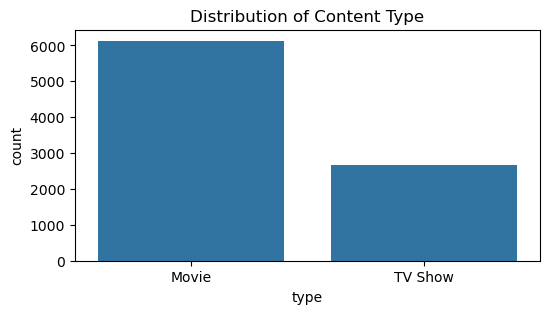

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,3))
sns.countplot(x='type', data=data)
plt.title("Distribution of Content Type")
plt.show()

### Yearly Release Trend

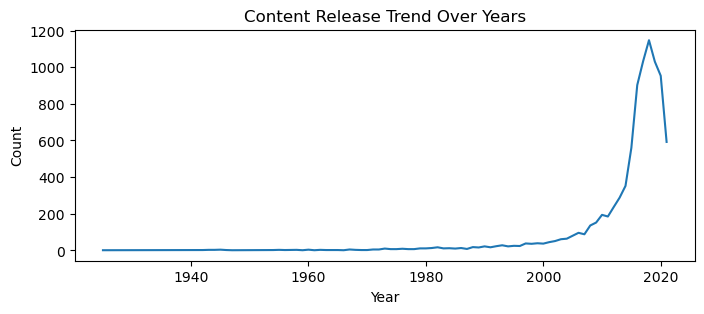

In [12]:
year_trend = data['release_year'].value_counts().sort_index()

plt.figure(figsize=(8,3))
year_trend.plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Top 10 Genres

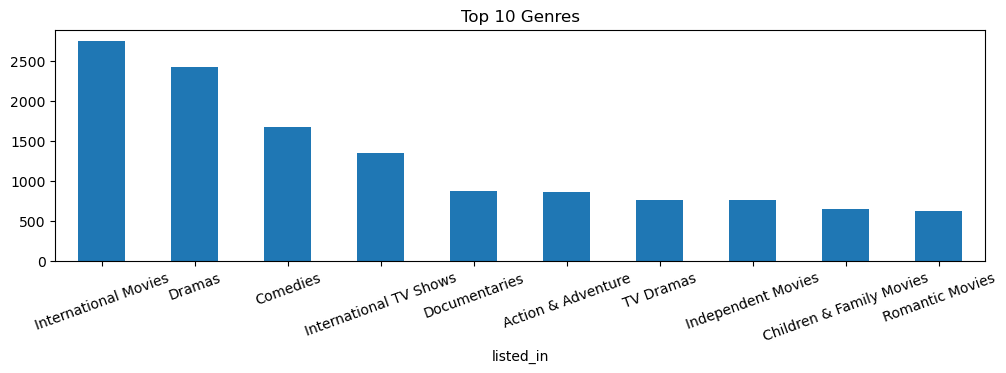

In [13]:
from collections import Counter
plt.figure(figsize=(12,3))
genres = data['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xticks(rotation=20)
plt.show()

### Runtime Distribution (Movies Only)

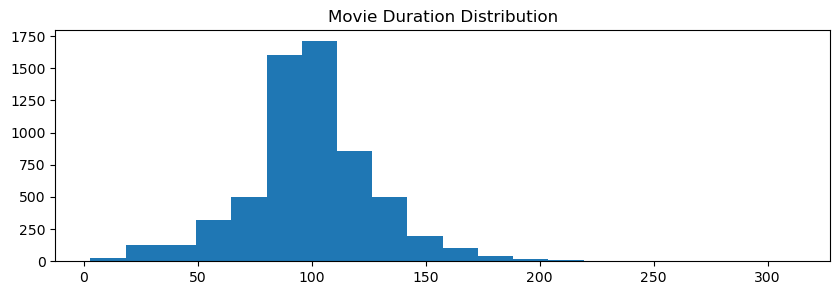

In [14]:
plt.figure(figsize=(10,3))
movies = data[data['type'] == 'Movie']
plt.hist(movies['duration'], bins=20)
plt.title("Movie Duration Distribution")
plt.show()

## STEP 4: Statistical Insights

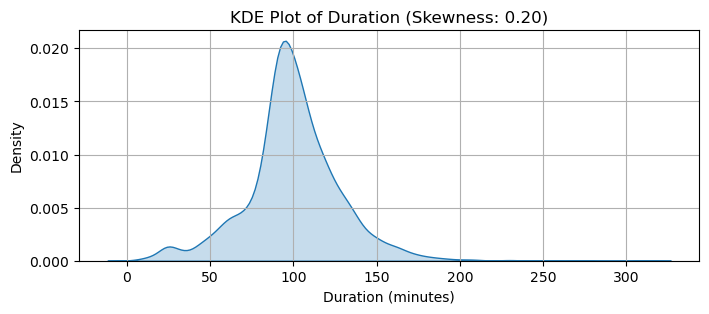

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate skewness
skewness_value = movies['duration'].skew()

# Plot
plt.figure(figsize=(8, 3))
sns.kdeplot(movies['duration'], fill=True)
plt.title(f"KDE Plot of Duration (Skewness: {skewness_value:.2f})")
plt.xlabel("Duration (minutes)")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [19]:
print(movies['duration'].skew())

0.2031712300131988


## STEP 5: Time-Based Growth Analysis

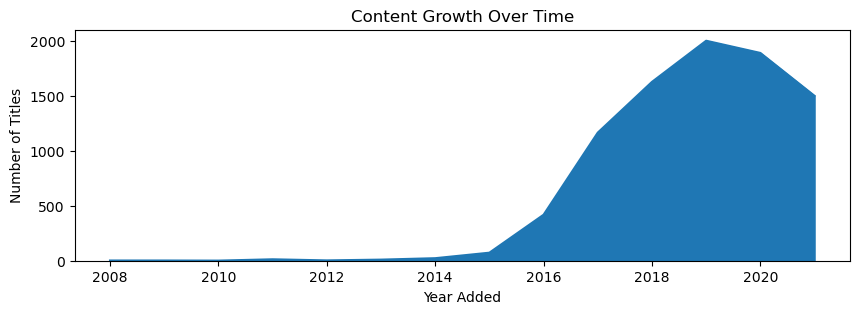

In [20]:
# Convert date_added to datetime (handle errors safely)
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')
data['year_added'] = data['date_added'].dt.year
data = data.dropna(subset=['year_added'])
data['year_added'] = data['year_added'].astype(int)

# Group and plot
plt.figure(figsize=(10,3))
growth = data.groupby('year_added').size()
growth.plot(kind='area')
plt.title("Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

## STEP 6: Machine Learning Component

### Feature Engineering

In [22]:
# Content Age
data['content_age'] = data['year_added'] - data['release_year']

# Is Movie (Binary Encoding)
data['is_movie'] = data['type'].map({'Movie': 1, 'TV Show': 0})

# Decade Feature
data['decade'] = (data['release_year'] // 10) * 10

## Classification Task
### Problem: Predict whether content is Movie or TV Show

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

x = data[['release_year', 'content_age', 'duration', 'decade']]
y = data['is_movie']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [32]:
lg = LogisticRegression(max_iter=1000)
lg.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
lg_pred_y = lg.predict(x_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, lg_pred_y))
print(classification_report(y_test, lg_pred_y))

Logistic Regression Accuracy: 0.9969418960244648
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       797
           1       1.00      1.00      1.00      1819

    accuracy                           1.00      2616
   macro avg       1.00      1.00      1.00      2616
weighted avg       1.00      1.00      1.00      2616



In [40]:
rf_pred_y = rf.predict(x_test)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred_y))
print(classification_report(y_test, rf_pred_y))

Random Forest Accuracy: 0.996177370030581
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       797
           1       1.00      1.00      1.00      1819

    accuracy                           1.00      2616
   macro avg       1.00      1.00      1.00      2616
weighted avg       1.00      1.00      1.00      2616



In [41]:
knn_pred_y = knn.predict(x_test)
print('K-Nearest Neighbors:', accuracy_score(y_test, rf_pred_y))
print(classification_report(y_test, rf_pred_y))

K-Nearest Neighbors: 0.996177370030581
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       797
           1       1.00      1.00      1.00      1819

    accuracy                           1.00      2616
   macro avg       1.00      1.00      1.00      2616
weighted avg       1.00      1.00      1.00      2616



### Create DataFrame

In [67]:
clf_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [0.9969, 0.9961, 0.9961]
})
clf_results

,Model,Accuracy
0,Logistic Regression,0.9969
1,Random Forest,0.9961
2,KNN,0.9961


### Plot Accuracy

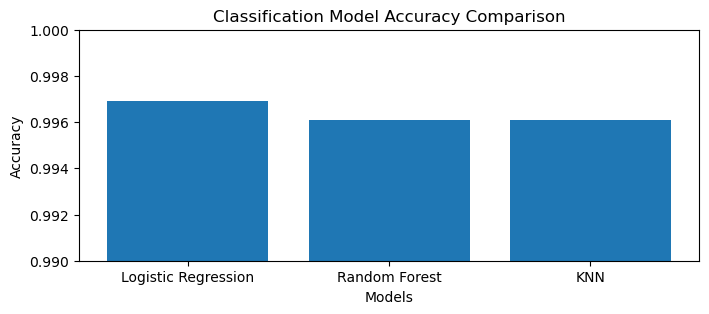

In [70]:
plt.figure(figsize=(8,3))
plt.bar(clf_results['Model'], clf_results['Accuracy'])
plt.title("Classification Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0.99, 1.00)  # Zoomed because values are very high
plt.show()

## REGRESSION TASK
### Problem: Predict duration (minutes)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

x_reg = data[['release_year', 'content_age', 'decade']]
y_reg = data['duration']

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x_reg, y_reg, test_size=0.4, random_state=42)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt = DecisionTreeRegressor(max_depth=5)
dt.fit(x_reg, y_reg)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [56]:
gb = GradientBoostingRegressor()
gb.fit(x_reg,y_reg)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [57]:
from sklearn.preprocessing import StandardScaler
svr = Pipeline([('scaler', StandardScaler()),('svr', SVR())])
svr.fit(x_reg, y_reg)

,steps,"[('scaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [58]:
dt_pred_y = dt.predict(x_test)
print('Decision Tree Result')
print('MSE:',mean_squared_error(y_test, dt_pred_y))
print('MAE:',mean_absolute_error(y_test, dt_pred_y))
print('R2 Score:',r2_score(y_test, dt_pred_y))

Decision Tree Result
MSE: 2202.392602027439
MAE: 40.01040258203778
R2 Score: 0.13690586540061633


In [59]:
gb_pred_y = gb.predict(x_test)
print('Gradient Boosting Result')
print('MSE:',mean_squared_error(y_test, gb_pred_y))
print('MAE:',mean_absolute_error(y_test, gb_pred_y))
print('R2 Score:',r2_score(y_test, gb_pred_y))

Gradient Boosting Result
MSE: 2151.0319846316665
MAE: 39.53032952220723
R2 Score: 0.15703354271976755


In [60]:
svr_pred_y = svr.predict(x_test)
print('Support Vector Result')
print('MSE:',mean_squared_error(y_test, svr_pred_y))
print('MAE:',mean_absolute_error(y_test, svr_pred_y))
print('R2 Score:',r2_score(y_test, svr_pred_y))

Support Vector Result
MSE: 2459.2337599841635
MAE: 39.02896250584391
R2 Score: 0.036252559195312783


### Create Comparison DataFrame

In [61]:
reg_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Gradient Boosting', 'SVR'],
    'R2 Score': [0.1369, 0.1570, 0.0362],
    'MAE': [40.01, 39.53, 39.02],
    'MSE': [2202.39, 2151.03, 2459.23]
})
reg_results

,Model,R2 Score,MAE,MSE
0,Decision Tree,0.1369,40.01,2202.39
1,Gradient Boosting,0.1570,39.53,2151.03
2,SVR,0.0362,39.02,2459.23


### Plot R² Comparison

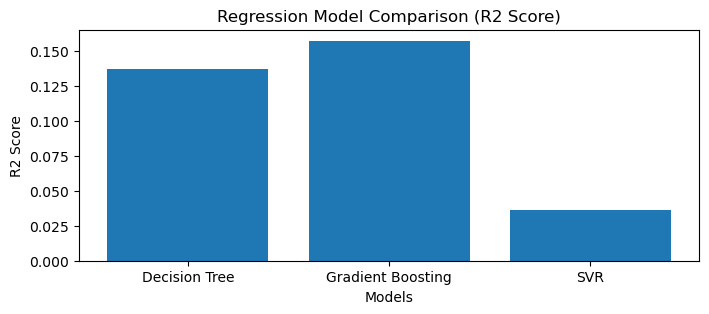

In [64]:
plt.figure(figsize=(8,3))
plt.bar(reg_results['Model'], reg_results['R2 Score'])
plt.title("Regression Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xlabel("Models")
plt.show()

### Plot MAE Comparison

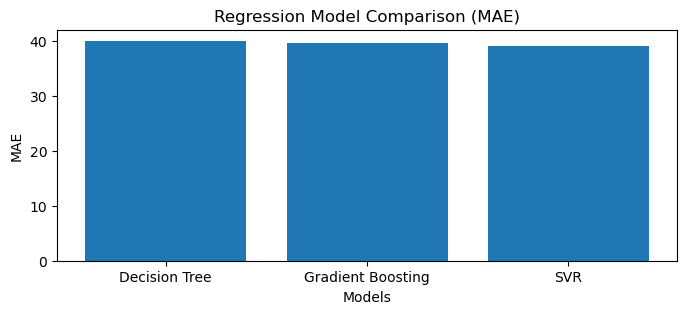

In [66]:
plt.figure(figsize=(8,3))
plt.bar(reg_results['Model'], reg_results['MAE'])
plt.title("Regression Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xlabel("Models")
plt.show()